<a href="https://colab.research.google.com/github/ShilpaVasista/Exploratory-Data-Analytics/blob/main/module_4_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1: Consider the following Python code:

```
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-14', '2017-01-15', '2017-01-16',
                  '2017-01-17', '2017-01-18', '2017-02-01',
                  '2017-02-15', '2017-02-28'],
    'load_MW':   [4200, 4350, 4100, 4500, 4250, 3900, 4050, 3800]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
print(df.loc['2017-01'])
print(df.loc['2017-01-15':'2017-01-18'])
print(df.resample('M').mean())

```

(i) Write the output of each of the three print statements.

(ii) Distinguish between loc-based date slicing and resample() with monthly frequency.



In [9]:
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-14', '2017-01-15', '2017-01-16',
                  '2017-01-17', '2017-01-18', '2017-02-01',
                  '2017-02-15', '2017-02-28'],
    'load_MW':   [4200, 4350, 4100, 4500, 4250, 3900, 4050, 3800]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
print(df.loc['2017-01'])
print(df.loc['2017-01-15':'2017-01-18'])
print(df.resample('M').mean())

            load_MW
timestamp          
2017-01-14     4200
2017-01-15     4350
2017-01-16     4100
2017-01-17     4500
2017-01-18     4250
            load_MW
timestamp          
2017-01-15     4350
2017-01-16     4100
2017-01-17     4500
2017-01-18     4250
                load_MW
timestamp              
2017-01-31  4280.000000
2017-02-28  3916.666667


/tmp/ipykernel_1352/3334423582.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  print(df.resample('M').mean())


#### (ii) Distinction between `loc`-based date slicing and `resample()` with monthly frequency

*   **`loc`-based date slicing (`df.loc['2017-01']` and `df.loc['2017-01-15':'2017-01-18']`)**:
    *   `loc`-based slicing is used to **select a subset of rows** from the DataFrame based on date labels in the index. It returns the original data points that fall within the specified date range or period.
    *   It's a form of **filtering** the data.
    *   For example, `df.loc['2017-01']` selects all rows with dates in January 2017, and `df.loc['2017-01-15':'2017-01-18']` selects rows from January 15th to January 18th, inclusive.

*   **`resample('M').mean()`**:
    *   `resample()` is used to **change the frequency** of the time series data. When used with an aggregation function like `mean()`, it **groups the data by the new frequency** (e.g., monthly) and then calculates the specified aggregate for each group.
    *   It's a form of **aggregation or transformation** of the data, which often reduces the number of rows and summarizes the data.
    *   For example, `df.resample('M').mean()` groups all data points by month and then calculates the average `load_MW` for each month, resulting in a new DataFrame with one row per month, representing the monthly average.

Q2: Consider the following power consumption dataset:

```
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-01', '2017-01-02', '2017-01-02',
                  '2017-01-03', '2017-01-04', '2017-01-05'],
    'load_MW':   [4200, 4350, 4350, None, 4250, 4100]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
print(df)
```

Write Python code to:

(i) Detect and remove the duplicate timestamp entry.

(ii) Identify and handle the NaN value using forward fill.


In [2]:
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-01', '2017-01-02', '2017-01-02',
                  '2017-01-03', '2017-01-04', '2017-01-05'],
    'load_MW':   [4200, 4350, 4350, None, 4250, 4100]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

print("Original DataFrame:")
print(df)

# (i) Detect and remove the duplicate timestamp entry
# To detect duplicates in the index, we can use df.index.duplicated()
# To keep the first occurrence and remove subsequent duplicates:
df_no_duplicates = df[~df.index.duplicated(keep='first')]
print("\nDataFrame after removing duplicate timestamps (keeping first occurrence):")
print(df_no_duplicates)

# (ii) Identify and handle the NaN value using forward fill
# Forward fill propagates the last valid observation forward to next valid observation
df_filled = df_no_duplicates.ffill()
print("\nDataFrame after forward filling NaN values:")
print(df_filled)

Original DataFrame:
            load_MW
timestamp          
2017-01-01   4200.0
2017-01-02   4350.0
2017-01-02   4350.0
2017-01-03      NaN
2017-01-04   4250.0
2017-01-05   4100.0

DataFrame after removing duplicate timestamps (keeping first occurrence):
            load_MW
timestamp          
2017-01-01   4200.0
2017-01-02   4350.0
2017-01-03      NaN
2017-01-04   4250.0
2017-01-05   4100.0

DataFrame after forward filling NaN values:
            load_MW
timestamp          
2017-01-01   4200.0
2017-01-02   4350.0
2017-01-03   4350.0
2017-01-04   4250.0
2017-01-05   4100.0


Q3: Consider the following power consumption dataset:
```
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame({
    'timestamp': ['2017-01-01', '2017-01-02', '2017-01-03',
                  '2017-01-04', '2017-01-05'],
    'load_MW':   [4200, 4350, 4100, 4500, 4250]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
```
Using the provided `df` DataFrame with its `timestamp` as the index, write Python code to perform the following time series analyses and visualizations:

1.  **Visualize `load_MW` as a line chart with customisations:**
    *   Generate a line chart for the `load_MW` column.
    *   Include a clear and descriptive title for the chart.
    *   Provide informative labels for both the X-axis (Date/Timestamp) and Y-axis (Load in MW).
    *   Add a grid to the plot for enhanced readability.
    *   Display the generated plot.

2.  **Calculate and visualize daily changes:**
    *   Compute the daily difference (change) in `load_MW`.
    *   Visualize these daily changes as a line chart.
    *   Include an appropriate title and axis labels.



3.  **Interpret the visualizations:**
    *   Based on the plots, describe any observed trends or patterns in the `load_MW` data over this short period.

### Solution for Q3

#### 1. Visualize `load_MW` as a line chart with customisations

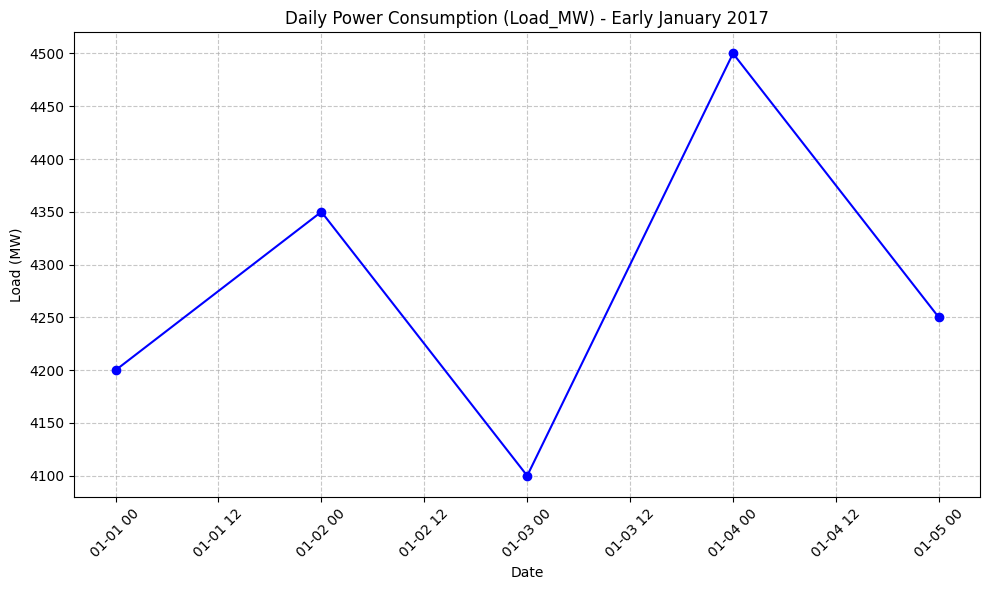

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Re-create the DataFrame as per Q3's context, if not already in kernel
df = pd.DataFrame({
    'timestamp': ['2017-01-01', '2017-01-02', '2017-01-03',
                  '2017-01-04', '2017-01-05'],
    'load_MW':   [4200, 4350, 4100, 4500, 4250]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['load_MW'], marker='o', linestyle='-', color='blue')
plt.title('Daily Power Consumption (Load_MW) - Early January 2017')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2. Calculate and visualize daily changes

timestamp
2017-01-01      NaN
2017-01-02    150.0
2017-01-03   -250.0
2017-01-04    400.0
2017-01-05   -250.0
Name: daily_change, dtype: float64


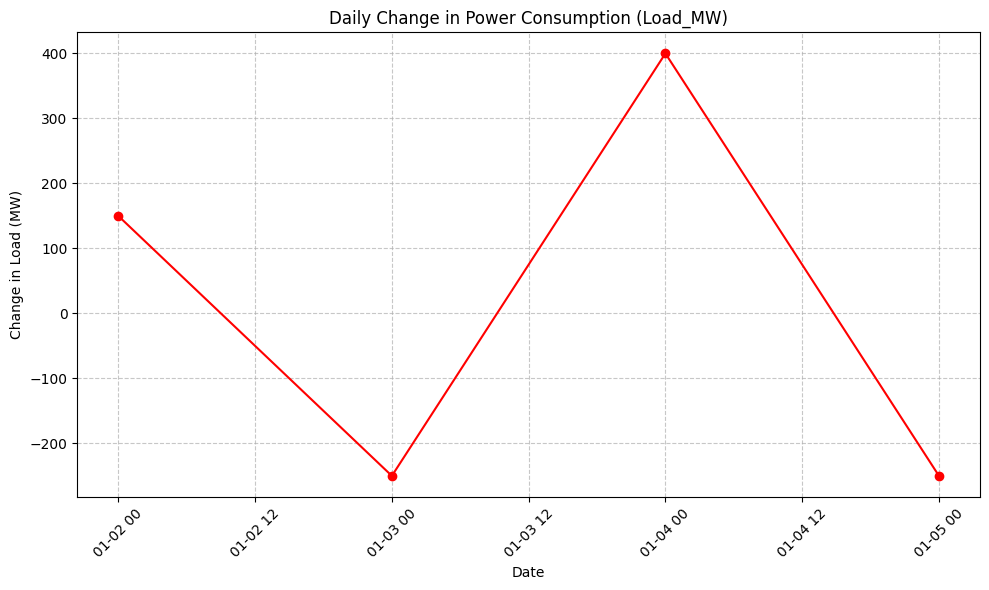

In [12]:
import matplotlib.pyplot as plt

# Calculate daily changes in load_MW
df['daily_change'] = df['load_MW'].diff()
print(df['daily_change'])

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['daily_change'], marker='o', linestyle='-', color='red')
plt.title('Daily Change in Power Consumption (Load_MW)')
plt.xlabel('Date')
plt.ylabel('Change in Load (MW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3. Interpret the visualizations

Based on the plots for `load_MW` and its daily changes over the period of January 1st to January 5th, 2017:

*   **Load_MW Visualization**: The first plot shows the raw power consumption data. We can observe a fluctuating pattern. The load starts at 4200 MW, increases to 4350 MW, drops to 4100 MW, peaks at 4500 MW, and then decreases slightly to 4250 MW. This short-term data does not clearly indicate a strong upward or downward trend, but rather day-to-day variability.

*   **Daily Changes Visualization**: The second plot highlights the day-to-day fluctuations more clearly.
    *   Jan 1 to Jan 2: Load increased by 150 MW.
    *   Jan 2 to Jan 3: Load decreased by 250 MW.
    *   Jan 3 to Jan 4: Load increased significantly by 400 MW.
    *   Jan 4 to Jan 5: Load decreased by 250 MW.
    
    The daily changes reveal that the largest increase occurred between Jan 3 and Jan 4, and the largest decreases occurred between Jan 2-3 and Jan 4-5. The changes are quite volatile over this very short period, suggesting significant variation in consumption from one day to the next without a consistent pattern emerging from only 5 days of data.

Q4: Consider the following Python code:
```
import pandas as pd
index = pd.date_range('2023-01-01', periods=10, freq='D')
df = pd.DataFrame({
    'Load_MW': [4200, 4350, 4100, 4500, 4250,
                3900, 4050, 3800, 4150, 4300]
}, index=index)
print(df.resample('W').mean())
print(df.resample('W').sum())
print(df.resample('M').max())
```
Write the output of each of the three print statements.


In [19]:
import pandas as pd
index = pd.date_range('2026-04-26', periods=10, freq='D')
df = pd.DataFrame({
    'Load_MW': [4200, 4350, 4100, 4500, 4250,
                3900, 4050, 3800, 4150, 4300]
}, index=index)

print("Original Dataframe")
print(df)

print("Output of df.resample('W').mean():")
print(df.resample('W').mean())
print("\nOutput of df.resample('W').sum():")
print(df.resample('W').sum())
print("\nOutput of df.resample('M').max():")
print(df.resample('ME').max())

Original Dataframe
            Load_MW
2026-04-26     4200
2026-04-27     4350
2026-04-28     4100
2026-04-29     4500
2026-04-30     4250
2026-05-01     3900
2026-05-02     4050
2026-05-03     3800
2026-05-04     4150
2026-05-05     4300
Output of df.resample('W').mean():
                Load_MW
2026-04-26  4200.000000
2026-05-03  4135.714286
2026-05-10  4225.000000

Output of df.resample('W').sum():
            Load_MW
2026-04-26     4200
2026-05-03    28950
2026-05-10     8450

Output of df.resample('M').max():
            Load_MW
2026-04-30     4500
2026-05-31     4300


Q5: Consider the following power consumption dataset:

```
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-10', '2017-01-20', '2017-02-10',
                  '2017-02-20', '2017-03-10', '2017-03-20'],
    'load_MW':   [4200, 4350, 3900, 4050, 4500, 4250]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
```
Write Python code to perform the following operations and interpret each result:

(i) Compute monthly mean of load_MW.

(ii) Extract the month component from the DatetimeIndex and compute average load_MW per month.


In [24]:
import pandas as pd

df = pd.DataFrame({
    'timestamp': ['2017-01-10', '2017-01-20', '2017-02-10',
                  '2017-02-20', '2017-03-10', '2017-03-20'],
    'load_MW':   [4200, 4350, 3900, 4050, 4500, 4250]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

print("Original DataFrame:")
print(df)

# (i) Compute monthly mean of load_MW
monthly_mean_resample = df.resample('ME').mean()
print("\n(i) Monthly mean of load_MW (using resample('M').mean()):")
print(monthly_mean_resample)
print("Interpretation: This output shows the average load_MW for each month based on the data points available. For January 2017, the average is (4200 + 4350) / 2 = 4275.0. Similarly for February and March.")
print()
print()

# (ii) Extract the month component from the DatetimeIndex and compute average load_MW per month.
# Extract month as an integer
df['month'] = df.index.month
print("\n(ii) Average load_MW per month (using groupby and extracted month component):")
print("Sample dataframe after adding month column")
print(df.head())
print()
monthly_mean_groupby = df.groupby('month')['load_MW'].mean()

print(monthly_mean_groupby)
print("Interpretation: This output shows the average load_MW for each distinct month number found in the dataset. Month 1 (January), Month 2 (February), and Month 3 (March) have their respective averages calculated. The results are identical to resample('M').mean() in this specific dataset because each month is represented, but resample handles the time series aspect more robustly, even if data points are sparse or irregular within a month.")

Original DataFrame:
            load_MW
timestamp          
2017-01-10     4200
2017-01-20     4350
2017-02-10     3900
2017-02-20     4050
2017-03-10     4500
2017-03-20     4250

(i) Monthly mean of load_MW (using resample('M').mean()):
            load_MW
timestamp          
2017-01-31   4275.0
2017-02-28   3975.0
2017-03-31   4375.0
Interpretation: This output shows the average load_MW for each month based on the data points available. For January 2017, the average is (4200 + 4350) / 2 = 4275.0. Similarly for February and March.



(ii) Average load_MW per month (using groupby and extracted month component):
Sample dataframe after adding month column
            load_MW  month
timestamp                 
2017-01-10     4200      1
2017-01-20     4350      1
2017-02-10     3900      2
2017-02-20     4050      2
2017-03-10     4500      3

month
1    4275.0
2    3975.0
3    4375.0
Name: load_MW, dtype: float64
Interpretation: This output shows the average load_MW for each distinct mon

Analyse the following time series EDA output for daily electricity consumption (in MW) over one year:

Monthly Average:

Jan=4200,

Feb=4100,

Mar=3900,

Jun=3600,


Sep=3700,

Dec=4500


Peak Day: Dec 21 (5100 MW)


Lowest Day: Jun 15 (3200 MW)


Overall Trend: Slightly increasing over the year

Identify the trend, seasonality, and any anomaly. What additional analysis would you perform?


### Solution for `70kV5v0UVwi_`

Analyse the time series EDA output for daily electricity consumption (in MW) over one year.

#### Identification of Trend, Seasonality, and Anomaly:

*   **Trend**: The "Overall Trend: Slightly increasing over the year" indicates a positive long-term trend in electricity consumption.

*   **Seasonality**: The monthly average values suggest strong seasonality:
    *   High consumption in winter months (Jan=4200, Dec=4500) and moderate in spring (Mar=3900).
    *   Lowest consumption in summer (Jun=3600), then starts increasing towards autumn (Sep=3700).
    *   This pattern (high in winter, low in summer) is typical for electricity consumption due to heating/cooling demands.

*   **Anomaly**: The "Peak Day: Dec 21 (5100 MW)" and "Lowest Day: Jun 15 (3200 MW)" are significant points. While they represent the extremes of consumption, they align with the seasonal pattern (peak in winter, low in summer). Without more context (e.g., historical data or specific events), they appear to be *seasonal extremes* rather than anomalies. An actual anomaly might be an unusually low December peak or an unusually high June consumption, deviating from the expected seasonal range.

#### Additional Analysis to Perform:

1.  **Granular Seasonality**: Investigate weekly and daily patterns. Are there differences between weekdays and weekends? Are there peak hours within a day?
2.  **External Factors Correlation**: Correlate consumption with external data such as:
    *   **Temperature**: This is a major driver of electricity demand (heating in winter, cooling in summer). Regression analysis could quantify this relationship.
    *   **Public Holidays/Special Events**: These can significantly alter consumption patterns.
    *   **Economic Indicators**: Industrial activity, economic growth, etc., can influence long-term trends.
3.  **Load Duration Curve**: Create a load duration curve to understand how long certain load levels are sustained. This is crucial for power system planning.
4.  **Forecast Accuracy**: If this is part of a forecasting task, evaluate the accuracy of any prediction models.
5.  **Outlier Detection**: Use statistical methods (e.g., Z-score, IQR) or machine learning algorithms to formally detect true outliers that might indicate data errors or unusual events (e.g., power outages, major industrial shutdowns).
6.  **Decomposition**: Decompose the time series into trend, seasonal, and residual components using techniques like STL (Seasonal-Trend decomposition using Loess) or moving averages to better isolate and understand each component.
7.  **Rolling Statistics**: Calculate rolling means and standard deviations to observe how consumption characteristics change over shorter periods and identify non-stationarity.

Describe the steps involved in performing EDA on the Open Power System dataset. Provide a step-by-step explanation for each of the following:

(i) Loading the dataset and setting up time-based indexing using parse_dates and index_col.

(ii) Data cleaning — identifying and handling NaN values using dropna() and fillna().

(iii) Visualising monthly trends by resampling the data using resample('M').mean() and plotting using df.plot().


### Solution for `novqybI2V9k_`

Describe the steps involved in performing EDA on the Open Power System dataset.

#### (i) Loading the dataset and setting up time-based indexing using `parse_dates` and `index_col`.

1.  **Import Pandas**: Start by importing the pandas library.
    ```python
    import pandas as pd
    ```
2.  **Load the Dataset**: Use `pd.read_csv()` to load your dataset. The `parse_dates` parameter should be set to a list of column names that contain date/time information, which pandas will then try to convert into `datetime` objects. The `index_col` parameter specifies the column to be used as the DataFrame index. For time series, this is typically the timestamp column.
    ```python
    # Assuming your CSV is named 'opsd_germany_daily.csv' and has a 'Date' column for timestamps
    df = pd.read_csv('opsd_germany_daily.csv', parse_dates=['Date'], index_col='Date')
    ```
3.  **Verify Index**: After loading, it's good practice to verify that the index is indeed a `DatetimeIndex` and that the data types are correct.
    ```python
    print(df.info())
    ```

#### (ii) Data cleaning — identifying and handling NaN values using `dropna()` and `fillna()`.

1.  **Identify Missing Values**: Check for `NaN` (Not a Number) values in your DataFrame. This gives an idea of where data is missing.
    ```python
    print(df.isnull().sum()) # Shows count of NaNs per column
    ```
2.  **Handling Missing Values (Strategy depends on context)**:
    *   **`dropna()` (Drop rows/columns with NaNs)**: If only a small percentage of rows have missing data, or if an entire column is mostly empty and not crucial for analysis, you can drop them.
        ```python
        # Drop rows with any NaN values
        df_cleaned_drop_rows = df.dropna()
        # Drop columns with any NaN values
        df_cleaned_drop_cols = df.dropna(axis=1)
        ```
    *   **`fillna()` (Fill NaNs)**: More commonly, you'll want to impute missing values. Common strategies include:
        *   **Forward Fill (`ffill()`)**: Propagates the last valid observation forward to next valid observation. Suitable for time series where you assume the value remains constant until a new one appears.
            ```python
            df_filled_ffill = df.ffill()
            ```
        *   **Backward Fill (`bfill()`)**: Propagates the next valid observation backward to the current missing value. Useful if future values are more representative.
            ```python
            df_filled_bfill = df.bfill()
            ```
        *   **Mean/Median/Mode Imputation**: Fill `NaN`s with the mean, median, or mode of the column. This can be done for numerical data.
            ```python
            # Example for a specific column
            df['SomeColumn'] = df['SomeColumn'].fillna(df['SomeColumn'].mean())
            ```
        *   **Interpolation**: For time series, interpolation (e.g., linear) is often a good choice, as it estimates missing values based on surrounding points.
            ```python
            df_interpolated = df.interpolate(method='linear')
            ```

#### (iii) Visualising monthly trends by resampling the data using `resample('M').mean()` and plotting using `df.plot()`.

1.  **Resample to Monthly Frequency**: Use the `resample('M')` method on your DataFrame (which should have a `DatetimeIndex`) to group data by month. Then apply an aggregation function, commonly `mean()`, to summarize the data for each month.
    ```python
    # Assuming 'df' is your cleaned DataFrame with a DatetimeIndex
    monthly_mean_data = df.resample('M').mean()
    ```
2.  **Visualize Monthly Trends**: Use the `.plot()` method directly on the resampled DataFrame. Pandas will automatically use the `DatetimeIndex` for the x-axis and plot each numerical column as a separate line.
    ```python
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    monthly_mean_data['load_MW'].plot(title='Monthly Average Load (MW)') # Plotting a specific column if many exist
    plt.xlabel('Date')
    plt.ylabel('Average Load (MW)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # If you want to plot all numerical columns in the resampled data
    # monthly_mean_data.plot(figsize=(12, 6), title='Monthly Average Trends')
    # plt.xlabel('Date')
    # plt.ylabel('Average Value')
    # plt.grid(True, linestyle='--', alpha=0.7)
    # plt.tight_layout()
    # plt.show()
    ```
This process effectively transforms daily or hourly data into a monthly view, making it easier to observe seasonal patterns and long-term trends.

## Resources

### Common `resample()` Frequencies in Pandas

When using `resample()` in pandas, you specify an offset alias string for the frequency. Here are some common frequencies:

*   **Daily:** 'D' (Calendar day frequency)
*   **Weekly:** 'W' (Weekly frequency)
*   **Monthly:** 'ME' (Month end frequency) or 'MS' (Month start frequency)
*   **Quarterly:** 'QE' (Quarter end frequency) or 'QS' (Quarter start frequency)
*   **Annual:** 'YE' (Year end frequency) or 'YS' (Year start frequency)
*   **Hourly:** 'H' (Hourly frequency)
*   **Minutes:** 'min' (Minute frequency)
*   **Seconds:** 'S' (Second frequency)
*   **Business Day:** 'B' (Business day frequency)
*   **Custom Frequencies:** You can also specify multiples, e.g., '2D' for every two days, '3H' for every three hours.
*   **Anchored Frequencies:** E.g., 'W-MON' for weekly frequency anchored on Monday.